In [1]:
import scanpy as sc

In [12]:
import pandas as pd
import numpy as np

In [32]:
import matplotlib.pyplot as plt

In [35]:
from matplotlib import *
rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

In [2]:
ad = sc.read('data_h5ad/Insular_sorted_clusters.h5ad')

In [3]:
ad

AnnData object with n_obs × n_vars = 122663 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', '

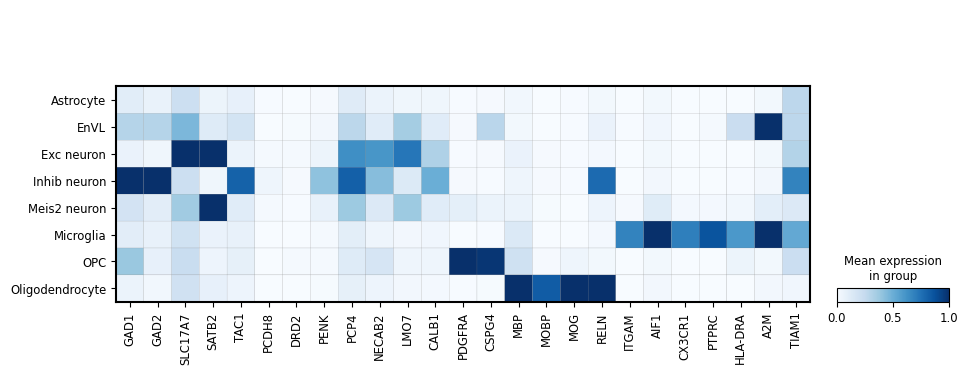

In [9]:
sc.pl.matrixplot(ad,groupby='cellTypeLabel',var_names=['GAD1','GAD2','SLC17A7','SATB2','TAC1','PCDH8','DRD2','PENK','PCP4','NECAB2','LMO7','CALB1','PDGFRA','CSPG4','MBP','MOBP','MOG','RELN','ITGAM','AIF1','CX3CR1','PTPRC','HLA-DRA','A2M','TIAM1'],cmap='Blues',vmax=1)

In [13]:
np.unique(ad.obs['cellTypeLabel'])

array(['Astrocyte', 'EnVL', 'Exc neuron', 'Inhib neuron', 'Meis2 neuron',
       'Microglia', 'OPC', 'Oligodendrocyte'], dtype=object)

In [14]:
ord = ['Inhib neuron','Exc neuron','OPC','Astrocyte','Oligodendrocyte','Microglia']

In [17]:
ad = ad[ad.obs['cellTypeLabel'].isin(ord),]

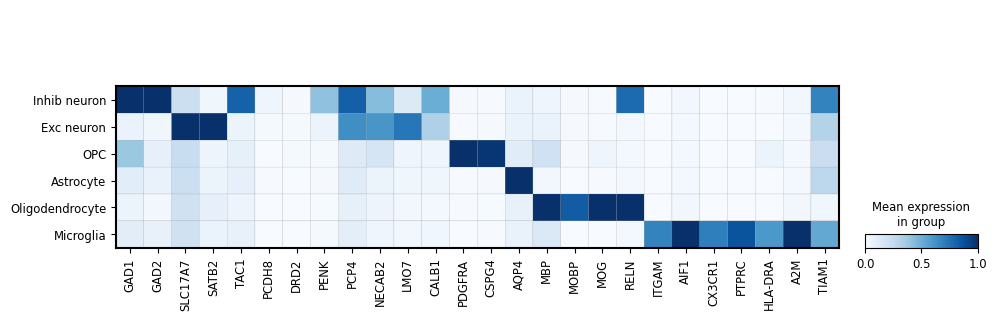

In [36]:
sc.pl.matrixplot(ad,groupby='cellTypeLabel',var_names=['GAD1','GAD2','SLC17A7','SATB2','TAC1','PCDH8','DRD2','PENK','PCP4','NECAB2','LMO7','CALB1','PDGFRA','CSPG4','AQP4','MBP','MOBP','MOG','RELN','ITGAM','AIF1','CX3CR1','PTPRC','HLA-DRA','A2M','TIAM1'],categories_order=ord,cmap='Blues',vmax=1,show=False)
plt.savefig('Figures/matrixplot_ins.pdf')

In [20]:
ad_acc = sc.read('data_processed_all/acc_label_main.h5ad')
ad_cn = sc.read('data_processed_all/cn_label_main.h5ad')
ad_cer = sc.read('data_processed_all/cer_label_main.h5ad')

In [24]:
ad_cn.obs['label_main']

H_AAACCTGTCTACGAGT-1        Oligo
H_AAACGGGAGCGTGAAC-1           IN
H_AAACGGGCACATAACC-1           IN
H_AAACGGGTCATTTGGG-1           EX
H_AAACGGGTCCGCGGTA-1        Oligo
                          ...    
M_TTTGCGCAGTCCGGTC-6           EX
M_TTTGCGCGTGGTACAG-6    Astrocyte
M_TTTGGTTTCTTAGAGC-6           EX
M_TTTGTCAAGACTTGAA-6    Astrocyte
M_TTTGTCAGTCCGAACC-6           EX
Name: label_main, Length: 25838, dtype: category
Categories (6, object): ['Astrocyte', 'EX', 'IN', 'Microglia', 'OPC', 'Oligo']

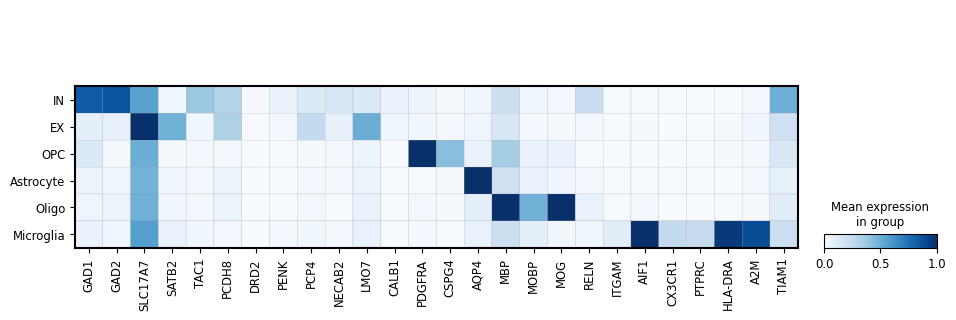

In [37]:
markers_ = ['GAD1','GAD2','SLC17A7','SATB2','TAC1','PCDH8','DRD2','PENK','PCP4','NECAB2','LMO7','CALB1','PDGFRA','CSPG4','AQP4','MBP','MOBP','MOG','RELN','ITGAM','AIF1','CX3CR1','PTPRC','HLA-DRA','A2M','TIAM1']
sc.pl.matrixplot(ad_acc,groupby='label_main',var_names=markers_,categories_order=['IN','EX','OPC','Astrocyte','Oligo','Microglia'],cmap='Blues',vmax=1,show=False)
plt.savefig('Figures/matrixplot_acc.pdf')

In [28]:
markers_ = ['GAD1','GAD2','SLC17A7','SATB2','TAC1','PCDH8','DRD2','PENK','PCP4','NECAB2','LMO7','CALB1','PDGFRA','CSPG4','AQP4','MBP','MOBP','MOG','RELN','ITGAM','AIF1','CX3CR1','PTPRC','HLA-DRA','A2M','TIAM1']
sc.pl.matrixplot(ad_cn,groupby='label_main',var_names=markers_,categories_order=['IN','EX','OPC','Astrocyte','Oligo','Microglia'],cmap='Blues',vmax=1)


KeyError: "Could not find keys '['CX3CR1', 'SLC17A7']' in columns of `adata.obs` or in adata.var_names."

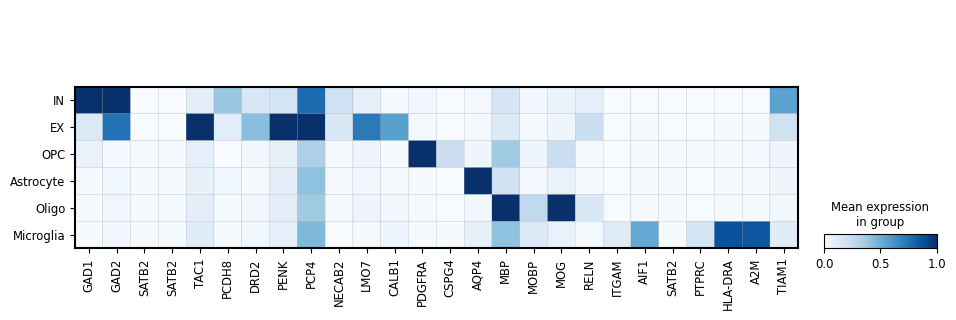

In [38]:
markers_ = ['GAD1','GAD2','SATB2','SATB2','TAC1','PCDH8','DRD2','PENK','PCP4','NECAB2','LMO7','CALB1','PDGFRA','CSPG4','AQP4','MBP','MOBP','MOG','RELN','ITGAM','AIF1','SATB2','PTPRC','HLA-DRA','A2M','TIAM1']
sc.pl.matrixplot(ad_cn,groupby='label_main',var_names=markers_,categories_order=['IN','EX','OPC','Astrocyte','Oligo','Microglia'],cmap='Blues',vmax=1,show=False)
plt.savefig('Figures/matrixplot_cn.pdf')

In [30]:
markers_ = ['GAD1','GAD2','SLC17A7','SATB2','TAC1','PCDH8','DRD2','PENK','PCP4','NECAB2','LMO7','CALB1','PDGFRA','CSPG4','AQP4','MBP','MOBP','MOG','RELN','ITGAM','AIF1','CX3CR1','PTPRC','HLA-DRA','A2M','TIAM1']
sc.pl.matrixplot(ad_cer,groupby='label_main',var_names=markers_,categories_order=['IN','Astrocyte','Oligo','Neu'],cmap='Blues',vmax=1)

KeyError: "Could not find keys '['A2M', 'AIF1', 'CSPG4', 'CX3CR1', 'DRD2', 'ITGAM', 'NECAB2', 'PCDH8', 'PTPRC', 'SATB2', 'TAC1']' in columns of `adata.obs` or in adata.var_names."

In [29]:
np.unique(ad_cer.obs['label_main'])

array(['Astrocyte', 'IN', 'Neu', 'Oligo'], dtype=object)

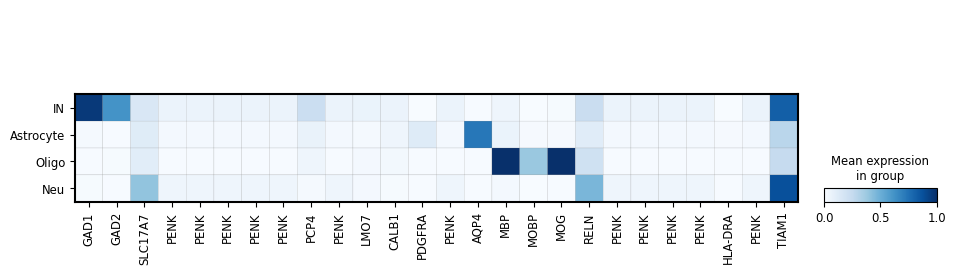

In [39]:
markers_ = ['GAD1','GAD2','SLC17A7','PENK','PENK','PENK','PENK','PENK','PCP4','PENK','LMO7','CALB1','PDGFRA','PENK','AQP4','MBP','MOBP','MOG','RELN','PENK','PENK','PENK','PENK','HLA-DRA','PENK','TIAM1']
sc.pl.matrixplot(ad_cer,groupby='label_main',var_names=markers_,categories_order=['IN','Astrocyte','Oligo','Neu'],cmap='Blues',vmax=1,show=False)
plt.savefig('Figures/matrixplot_cer.pdf')